# Neighbour-based Prediction within Geographic Clusters (calendar months)

**Goal.** For each site, measure how well its **20 km cluster-mates** predict and *bracket*
its monthly KPIs — on the **real calendar axis** (2024-01 … 2026-03), with **no
opening-date / "site age" assumption** (the data is a fixed calendar panel, not per-site
histories from opening, so an age axis would be mostly fictitious).

**Design:**
- **Timeline = calendar month.** Every site is compared to its mates over the *same* real
  months, so seasonality and macro trends are shared, not confounded.
- **Leave-one-site-out.** Each held-out site is predicted only from its cluster-mates at the
  same calendar month (one fold per site), weighted by inverse distance (IDW).
- **Clusters = geographic 20 km** complete-linkage neighbourhoods (KPI-agnostic).
- **Baseline = global calendar curve** (the average of *all* sites each month). Uplift > 0
  means the local cluster beats "the average site that month".
- **Coverage (§5b).** Does the held-out site fall inside the *range* its mates span that
  month — vs an exchangeability null.

**Data note:** 2024 and 2025 are full 12-month years; **2026 is Q1 only (Jan–Mar)**. Site
count grows over the window (615 reporting in 2024-01 → ~1,520 by 2026-03).

The 5 KPIs: membership_purchased_count, membership_wash_count, asp_per_membership,
retail_wash_count, asp_per_retail_wash.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

# make the project's src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import load_all
from src.neighbours import haversine_km_vec
from src import config as C

plt.rcParams["figure.dpi"] = 110
KPIS   = C.TARGET_KPIS
LABELS = C.KPI_LABELS
MAXAGE = 24                      # two years of site age

ds = load_all()
sites, panels, month_axis = ds.sites.copy(), ds.panels, ds.month_axis
print(f"{len(sites):,} sites | {len(month_axis)} calendar months | KPIs: {KPIS}")

1,674 sites | 27 calendar months | KPIs: ['membership_purchased_count', 'membership_wash_count', 'asp_per_membership', 'retail_wash_count', 'asp_per_retail_wash']


## 1. Geographic 20 km clusters
Complete-linkage agglomerative clustering with a hard 20 km diameter cap (same
recipe as `cluster_pattern.ipynb`). We keep clusters with **≥2 sites** so every
held-out site has at least one neighbour to learn from.

In [2]:
Dkm = pairwise_distances(np.radians(sites[["lat", "lon"]].to_numpy()),
                         metric="haversine") * C.EARTH_KM
labels = AgglomerativeClustering(
    n_clusters=None, distance_threshold=C.BUFFER_KM,
    metric="precomputed", linkage="complete").fit(Dkm).labels_
sites["cluster"] = labels

vc = sites["cluster"].value_counts()
multi = vc[vc >= 2].index
sites["cluster"] = sites["cluster"].where(sites["cluster"].isin(multi), -1)
si = sites.set_index("site_uid")

print(f"clusters with >=2 sites : {len(multi)}")
print(f"sites inside a cluster   : {(sites.cluster >= 0).sum():,} / {len(sites):,}")
print(f"cluster size: median {int(vc[vc>=2].median())}, max {int(vc.max())}")

clusters with >=2 sites : 368
sites inside a cluster   : 1,305 / 1,674
cluster size: median 3, max 21


## 2. Site \u00d7 calendar-month matrix
`CAL[kpi]` is a `site_uid \u00d7 month` matrix on the real calendar axis (2024-01 \u2026 2026-03).
**No age re-indexing** \u2014 column *m* is simply that site's KPI in calendar month *m*, so two
sites in the same column are compared over the *same* real period.

In [3]:
CAL    = {k: panels[k].reindex(columns=month_axis) for k in KPIS}
GLOBAL = {k: CAL[k].mean(axis=0) for k in KPIS}      # global calendar curve (all sites)
YEARS  = sorted({m.year for m in month_axis})

cov = CAL["retail_wash_count"].notna().sum(axis=0)
print("calendar span:", month_axis.min().strftime('%Y-%m'), "->", month_axis.max().strftime('%Y-%m'))
print("sites reporting  2024-01:", int(cov.iloc[0]),
      "| 2025-01:", int(cov[month_axis[12]]), "| 2026-03:", int(cov.iloc[-1]))
print("months per calendar year:", {y: sum(m.year == y for m in month_axis) for y in YEARS})

calendar span: 2024-01 -> 2026-03
sites reporting  2024-01: 615 | 2025-01: 968 | 2026-03: 1522
months per calendar year: {2024: 12, 2025: 12, 2026: 3}


## 3. Prediction = IDW blend of cluster-mates at the same calendar month
For a held-out site we take the other sites in its cluster, weight them by inverse distance,
and average their value in each calendar month (renormalising over the mates that actually
report that month).

In [4]:
def predict_holdout(uid, kpi, agg="idw"):
    c = si.loc[uid, "cluster"]
    if c < 0:
        return None
    mates = si[(si.cluster == c) & (si.index != uid)]
    A = CAL[kpi].reindex(mates.index)
    if A.dropna(how="all").empty:
        return None
    d = haversine_km_vec(si.loc[uid, "lat"], si.loc[uid, "lon"],
                         mates.lat.values, mates.lon.values)
    w = 1.0 / (d + C.IDW_EPS_KM) if agg == "idw" else np.ones(len(mates))
    V = A.to_numpy(float)
    mask = ~np.isnan(V)
    W = w[:, None] * mask
    den = W.sum(axis=0)
    pred = np.where(den > 0, np.nansum(np.where(mask, W * V, 0.0), axis=0) / den, np.nan)
    return pd.Series(pred, index=A.columns)

# sanity: one held-out site
demo = si[si.cluster >= 0].index[0]
print("demo prediction (retail_wash_count) for", demo)
print({k.strftime('%Y-%m'): round(v) for k, v in
       predict_holdout(demo, "retail_wash_count").dropna().head(6).items()})

demo prediction (retail_wash_count) for 360 Car Wash__1
{'2024-03': 2001, '2024-04': 2710, '2024-05': 2286, '2024-06': 3000, '2024-07': 2383, '2024-08': 3503}


## 4. Leave-one-site-out across every cluster (calendar months)
For each held-out site \u00d7 KPI we record predicted, actual and global-baseline values at every
calendar month, then tag each month by its calendar year.

In [5]:
def smape(a, p):
    return float(np.mean(2 * np.abs(p - a) / (np.abs(p) + np.abs(a) + 1e-9)))

SYNC_MIN_MONTHS = 6      # a Pearson r over <6 months is unstable (e.g. 2026 Q1) -> report NaN

def _sync(av, pv):
    return (pearsonr(av, pv)[0]
            if (len(av) >= SYNC_MIN_MONTHS and av.std() > 0 and pv.std() > 0) else np.nan)

year_rows, all_rows, month_rows = [], [], []
for uid in si[si.cluster >= 0].index:
    for kpi in KPIS:
        pred = predict_holdout(uid, kpi)
        if pred is None:
            continue
        actual, base = CAL[kpi].loc[uid], GLOBAL[kpi]
        # per-month long records (for the drift curve)
        for m in month_axis:
            a, p = actual[m], pred[m]
            if np.isfinite(a) and np.isfinite(p):
                month_rows.append((kpi, m, abs(p - a),
                                   2 * abs(p - a) / (abs(p) + abs(a) + 1e-9)))
        # OVERALL across all calendar months: 2026 fully included AND sync_r is meaningful
        # because the series can span up to 27 months.
        mk = actual.notna() & pred.notna()
        if mk.sum() >= C.MIN_OVERLAP_MONTHS:
            av, pv, gv = actual[mk].to_numpy(), pred[mk].to_numpy(), base[mk].to_numpy()
            all_rows.append(dict(site=uid, kpi=kpi, n=int(mk.sum()),
                                 mae=np.mean(np.abs(pv - av)), smape=smape(av, pv),
                                 r=_sync(av, pv), mae_base=np.mean(np.abs(gv - av))))
        # per calendar-year: level metrics for every year (incl. 2026 Q1); sync_r only
        # where >=6 months exist, so 2026's 3-point correlation is suppressed, not faked.
        for yr in YEARS:
            cols = [m for m in month_axis if m.year == yr]
            a, p, g = actual[cols], pred[cols], base[cols]
            mky = a.notna() & p.notna()
            if mky.sum() < C.MIN_OVERLAP_MONTHS:
                continue
            av, pv, gv = a[mky].to_numpy(), p[mky].to_numpy(), g[mky].to_numpy()
            year_rows.append(dict(site=uid, kpi=kpi, year=yr, n=int(mky.sum()),
                                  mae=np.mean(np.abs(pv - av)), smape=smape(av, pv),
                                  r=_sync(av, pv), mae_base=np.mean(np.abs(gv - av))))

res = pd.DataFrame(year_rows)
res_all = pd.DataFrame(all_rows)
month_err = pd.DataFrame(month_rows, columns=["kpi", "month", "abs_err", "smape"])
print(f"scored {len(res):,} per-year + {len(res_all):,} overall folds across "
      f"{res.site.nunique():,} sites  (sync_r requires >={SYNC_MIN_MONTHS} months)")

scored 13,270 per-year + 6,040 overall folds across 1,203 sites  (sync_r requires >=6 months)


## 5. Scorecard \u2014 per calendar year + overall
`sync_r` = median Pearson correlation between predicted and actual over the period's months;
`uplift%` = how much the local cluster beats the global baseline on MAE. **2026 is Q1 only**, so
its per-year `sync_r` is **suppressed** (a 3-point correlation is meaningless) while its MAE / sMAPE
/ uplift stay valid \u2014 and its months still feed the **overall** row, where the full 2024\u20132026
series makes `sync_r` meaningful.

In [6]:
order = ["retail_wash_count", "membership_wash_count", "membership_purchased_count",
         "asp_per_membership", "asp_per_retail_wash"]

def scorecard(df, by):
    g = (df.groupby(by)
         .agg(n_folds=("mae", "size"), MAE=("mae", "median"), sMAPE=("smape", "median"),
              sync_r=("r", "median"), MAE_base=("mae_base", "median")).reset_index())
    g["uplift_%"] = (100 * (g.MAE_base - g.MAE) / g.MAE_base).round(1)
    g["label"] = g.kpi.map(LABELS)
    g = g.round({"MAE": 1, "sMAPE": 3, "sync_r": 3, "MAE_base": 1})
    g["kpi"] = pd.Categorical(g.kpi, order, ordered=True)
    return g.sort_values(by)

summary = scorecard(res, ["kpi", "year"])           # sync_r blank for 2026 (Q1, <6 months)
overall = scorecard(res_all, ["kpi"])               # all months -> sync_r & uplift meaningful
print("Per calendar year (2026 = Q1: level metrics valid, sync_r suppressed):")
display(summary[["label", "year", "n_folds", "MAE", "sMAPE", "sync_r", "MAE_base", "uplift_%"]])
print("\nOverall across all months 2024-2026 (full series; this is where 2026 strengthens sync_r):")
display(overall[["label", "n_folds", "MAE", "sMAPE", "sync_r", "MAE_base", "uplift_%"]])

Per calendar year (2026 = Q1: level metrics valid, sync_r suppressed):


,label,year,n_folds,MAE,sMAPE,sync_r,MAE_base,uplift_%
12,Retail washes,2024,464,1202.1,0.430,0.876,1143.9,-5.1
13,Retail washes,2025,1095,1019.8,0.413,0.853,1046.9,2.6
14,Retail washes,2026,1095,1008.2,0.383,NaN,1115.0,9.6
9,Membership washes,2024,464,2184.1,0.683,0.808,2708.3,19.4
10,Membership washes,2025,1095,2508.1,0.635,0.748,2868.7,12.6
11,Membership washes,2026,1095,2310.4,0.581,NaN,2989.8,22.7
6,Memberships sold,2024,464,834.4,0.715,0.462,912.8,8.6
7,Memberships sold,2025,1095,967.9,0.701,0.326,1067.0,9.3
8,Memberships sold,2026,1095,906.2,0.628,NaN,1061.6,14.6
0,ASP / membership ($),2024,464,4.4,0.151,0.359,5.6,20.7



Overall across all months 2024-2026 (full series; this is where 2026 strengthens sync_r):


,label,n_folds,MAE,sMAPE,sync_r,MAE_base,uplift_%
4,Retail washes,1208,1068.5,0.431,0.801,1101.4,3.0
3,Membership washes,1208,2498.7,0.643,0.694,2956.8,15.5
2,Memberships sold,1208,990.9,0.707,0.426,1062.1,6.7
0,ASP / membership ($),1208,4.4,0.152,0.336,4.8,7.3
1,ASP / retail wash ($),1208,3.4,0.269,0.210,2.8,-19.8


## 5b. State-wise leave-one-out containment (annual)

A concrete **range** test. Collapse each site to its **annual value** for each of the 5 KPIs
(2024, 2025). Then **per cluster**: leave one site out, take the **[min, max]** of the remaining
sites, and check whether the held-out site falls inside that range. Repeat for every site \u2192 each
cluster gets a **score = in-range checks / total checks**; average those **by state**.

- Needs **\u22653 sites** in a cluster (so leaving one out still leaves \u22652 to form a range).
- **Chance baseline:** a random site lands inside *m* mates' min\u2013max with probability
  **(m\u22121)/(m+1)** \u2014 the bar each cluster's score must clear to mean anything.
- Split by calendar year **2024 vs 2025** (2026 is Q1 only, excluded here).

In [7]:
# Aggregate each site to its ANNUAL value per metric, then per cluster leave one site out,
# build [min,max] from the others, and test if the held-out site lands inside (for each KPI).
cal_year = np.array([m.year for m in month_axis])

def annual_frame(year):
    cols = [m for m, yy in zip(month_axis, cal_year) if yy == year]
    out = {}
    for k in KPIS:
        sub = panels[k].reindex(columns=cols)
        out[k] = sub.mean(axis=1).where(sub.notna().sum(axis=1) >= 3)   # need >=3 months
    return out

def simulate(year):
    AN = annual_frame(year); rows = []
    for c, grp in si[si.cluster >= 0].groupby("cluster"):
        state = grp["state"].mode().iat[0]
        mem = grp.index
        tot = true = 0; chance = []; permetric = {}
        for k in KPIS:
            v = AN[k].reindex(mem).dropna()
            if len(v) < 3:                       # need >=3 sites so LOO leaves a real range
                continue
            mt = tt = 0
            for uid in v.index:
                others = v.drop(uid)
                inside = others.min() <= v[uid] <= others.max()
                tt += 1; mt += int(inside); tot += 1; true += int(inside)
                chance.append((len(others) - 1) / (len(others) + 1))
            permetric[k] = mt / tt
        if tot == 0:
            continue
        rows.append(dict(state=state, cluster=c, n_sites=len(mem), checks=tot,
                         true=true, score=true / tot, chance=float(np.mean(chance)), **permetric))
    return pd.DataFrame(rows)

SIM = {y: simulate(y) for y in (2024, 2025)}
for y in (2024, 2025):
    df = SIM[y]
    print(f"{y}: {len(df)} clusters scored, {df.checks.sum():,} leave-one-out checks  |  "
          f"overall containment {df.true.sum()/df.checks.sum():.1%}  vs chance {df.chance.mean():.1%}")

2024: 73 clusters scored, 1,390 leave-one-out checks  |  overall containment 47.6%  vs chance 44.1%
2025: 175 clusters scored, 3,935 leave-one-out checks  |  overall containment 55.6%  vs chance 49.8%


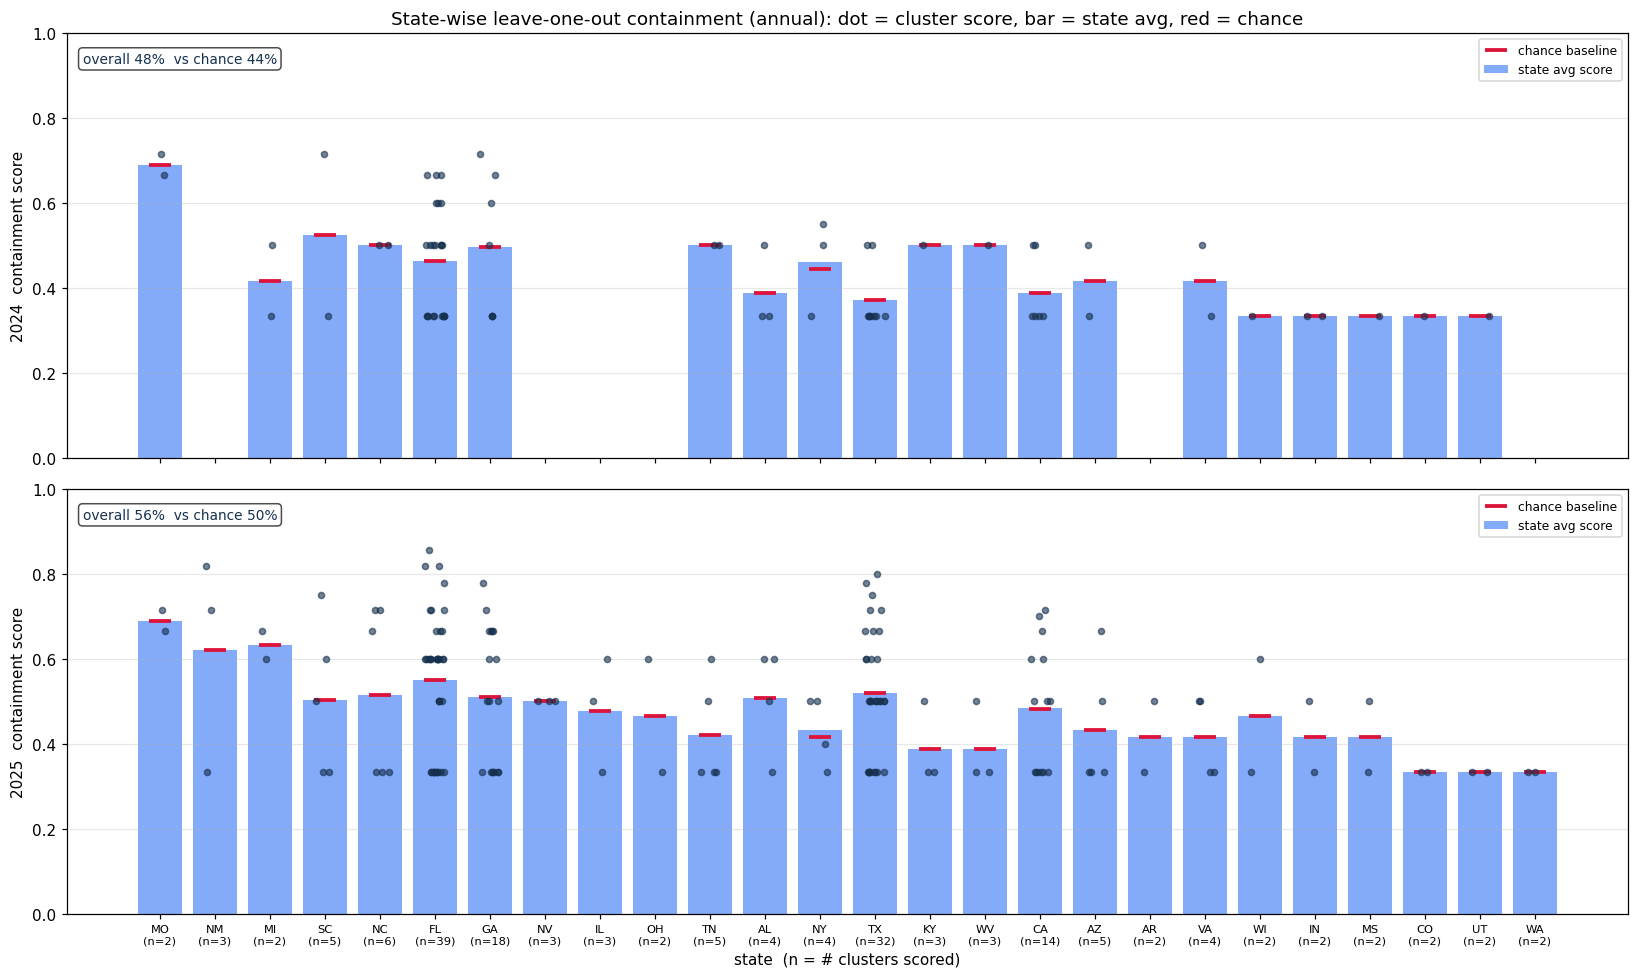

In [8]:
# Plot: each dot = one cluster's containment score, bar = state average, red = chance baseline.
allstates = sorted(set(SIM[2024].state) | set(SIM[2025].state))
state_order = [s for s in allstates if max((SIM[y].state == s).sum() for y in (2024, 2025)) >= 2]
state_order = sorted(state_order,
                     key=lambda s: -np.nanmean([SIM[y].loc[SIM[y].state == s, "score"].mean()
                                                for y in (2024, 2025)]))
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
rng = np.random.RandomState(0)
for ax, y in zip(axes, (2024, 2025)):
    df = SIM[y]; x = np.arange(len(state_order))
    savg = [df.loc[df.state == s, "score"].mean()  if (df.state == s).any() else np.nan for s in state_order]
    cavg = [df.loc[df.state == s, "chance"].mean() if (df.state == s).any() else np.nan for s in state_order]
    ncl  = [int((df.state == s).sum()) for s in state_order]
    ax.bar(x, savg, color="#5B8FF9", alpha=.75, label="state avg score")
    for i, s in enumerate(state_order):
        sc = df.loc[df.state == s, "score"].values
        ax.scatter(np.full(len(sc), i) + rng.uniform(-.18, .18, len(sc)), sc, s=16,
                   color="#16314f", alpha=.6, zorder=3)
    ax.plot(x, cavg, "_", color="crimson", ms=15, mew=2.5, label="chance baseline")
    ax.set_xticks(x); ax.set_xticklabels([f"{s}\n(n={n})" for s, n in zip(state_order, ncl)], fontsize=7.5)
    ax.set_ylabel(f"{y}  containment score"); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=.3)
    ax.legend(loc="upper right", fontsize=8)
    ov, ch = df.true.sum() / df.checks.sum(), df.chance.mean()
    ax.text(0.01, 0.93, f"overall {ov:.0%}  vs chance {ch:.0%}", transform=ax.transAxes,
            fontsize=9, color="#16314f", bbox=dict(boxstyle="round", fc="white", alpha=.7))
axes[0].set_title("State-wise leave-one-out containment (annual): dot = cluster score, bar = state avg, red = chance")
axes[1].set_xlabel("state  (n = # clusters scored)")
plt.tight_layout(); plt.show()

In [9]:
# State summary + a worked per-cluster example, and which of the 5 metrics is most contained.
def state_summary(df):
    g = (df.groupby("state").agg(n_clusters=("cluster", "size"), avg_score=("score", "mean"),
                                 avg_chance=("chance", "mean"), checks=("checks", "sum")).reset_index())
    g["lift_pp"]   = (100 * (g.avg_score - g.avg_chance)).round(1)
    g["avg_score"] = (100 * g.avg_score).round(1)
    g["avg_chance"]= (100 * g.avg_chance).round(1)
    return g.sort_values("avg_score", ascending=False)

ss = state_summary(SIM[2025])
print("2025 state summary (top 6 / bottom 3 by containment score; lift_pp = score - chance):")
display(pd.concat([ss.head(6), ss.tail(3)])[["state", "n_clusters", "avg_score", "avg_chance", "lift_pp", "checks"]])

ex = "GA"
d = SIM[2024][SIM[2024].state == ex].sort_values("score", ascending=False)
d = d.assign(result=d.true.astype(str) + "/" + d.checks.astype(str), score_pct=(100 * d.score).round(0))
print(f"\nWorked example \u2014 {ex} 2024, per cluster (result = in-range checks / total):")
display(d[["cluster", "n_sites", "result", "score_pct", "chance"]].round({"chance": 2}))

pm = SIM[2025].reindex(columns=KPIS).mean().rename(index=LABELS).sort_values(ascending=False)
print("\nContainment score by metric (2025, avg over clusters):")
display((100 * pm).round(1).to_frame("in_range_%"))

2025 state summary (top 6 / bottom 3 by containment score; lift_pp = score - chance):


,state,n_clusters,avg_score,avg_chance,lift_pp,checks
12,MO,2,69.0,69.0,-0.0,65
11,MI,2,63.3,63.3,-0.0,55
17,NM,3,62.2,62.2,-0.0,105
5,FL,39,55.1,55.1,0.0,1015
24,TX,32,52.1,52.1,0.0,750
15,NC,6,51.6,51.6,0.0,145
7,IA,1,33.3,33.3,0.0,15
25,UT,2,33.3,33.3,0.0,30
27,WA,2,33.3,33.3,0.0,30



Worked example — GA 2024, per cluster (result = in-range checks / total):


,cluster,n_sites,result,score_pct,chance
24,64,7,25/35,71.0,0.71
1,10,6,20/30,67.0,0.67
21,57,9,15/25,60.0,0.60
8,20,5,10/20,50.0,0.50
30,74,4,5/15,33.0,0.33
53,168,6,5/15,33.0,0.33
56,199,6,5/15,33.0,0.33



Containment score by metric (2025, avg over clusters):


,in_range_%
ASP / membership ($),50.0
Memberships sold,49.9
Membership washes,49.8
Retail washes,49.8
ASP / retail wash ($),49.8


### 5b. Takeaways \u2014 state-wise containment

- **This min\u2013max test is *uninformative by construction*.** Leaving out a *middle* site always lands
  inside (the min and max are still present); leaving out an *extreme* always lands outside. So
  exactly 2 of *n* sites fall outside \u2192 **score = (n\u22122)/n for *any* data**, which is identical to the
  (m\u22121)/(m+1) chance line. That's why **every cluster's dot sits exactly on its chance marker**
  (GA: 7 sites \u2192 5/7, 6 \u2192 4/6, 9 \u2192 7/9 \u2026) and every state's lift \u2248 0.0.
- **So the score measures cluster *size*, not similarity.** The 2024\u21922025 rise (48%\u219256%) is purely
  bigger clusters (more sites \u2192 larger n \u2192 (n\u22122)/n higher), tracked exactly by the chance line.
- **To actually test "are neighbours alike", look at the *range itself*, not containment:** is the
  cluster's min\u2013max **narrower** than a random group's? (No \u2014 see the band-width check.) Or wrap a
  **calibrated** interval around the neighbour mean (the usable 50%/80% ranges). The real signal
  stays the **co-movement / uplift** in \u00a75 \u2014 a good *midpoint*, not a tight *range*.

## 6. Plot \u2014 prediction quality by calendar year
Left: trend-shape sync (Pearson r). Right: error rate (sMAPE, lower = better). Bars grouped by
calendar year. **2026 has no sync_r bar** by design (Q1 only, <6 months); its sMAPE bar is valid.

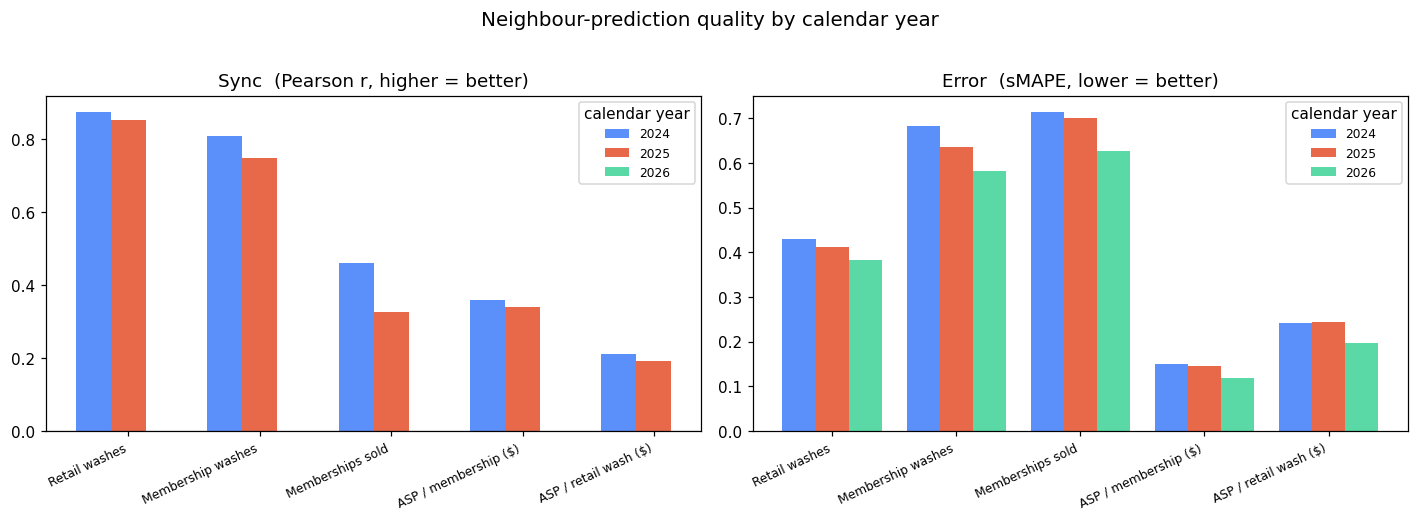

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
labs = [LABELS[k] for k in order]
x = np.arange(len(order)); wd = 0.8 / max(len(YEARS), 1)
palette = ["#5B8FF9", "#E8684A", "#5AD8A6", "#F6BD16"]
for ax, (col, title) in zip(axes, [("sync_r", "Sync  (Pearson r, higher = better)"),
                                    ("sMAPE", "Error  (sMAPE, lower = better)")]):
    piv = summary.pivot(index="kpi", columns="year", values=col).reindex(order)
    for i, yr in enumerate(YEARS):
        if yr not in piv.columns:
            continue
        ax.bar(x + (i - (len(YEARS) - 1) / 2) * wd, piv[yr].values, wd,
               label=str(yr), color=palette[i % len(palette)])
    ax.set_xticks(x); ax.set_xticklabels(labs, rotation=25, ha="right", fontsize=8)
    ax.set_title(title); ax.legend(title="calendar year", fontsize=8)
    if col == "sync_r":
        ax.axhline(0, color="grey", lw=.8)
fig.suptitle("Neighbour-prediction quality by calendar year", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 7. Plot \u2014 error over calendar time
Median sMAPE in each calendar month (2024-01 \u2026 2026-03), per KPI. Rising curves mean the
cluster predicts the held-out site worse in that period; flat-or-falling means stable.

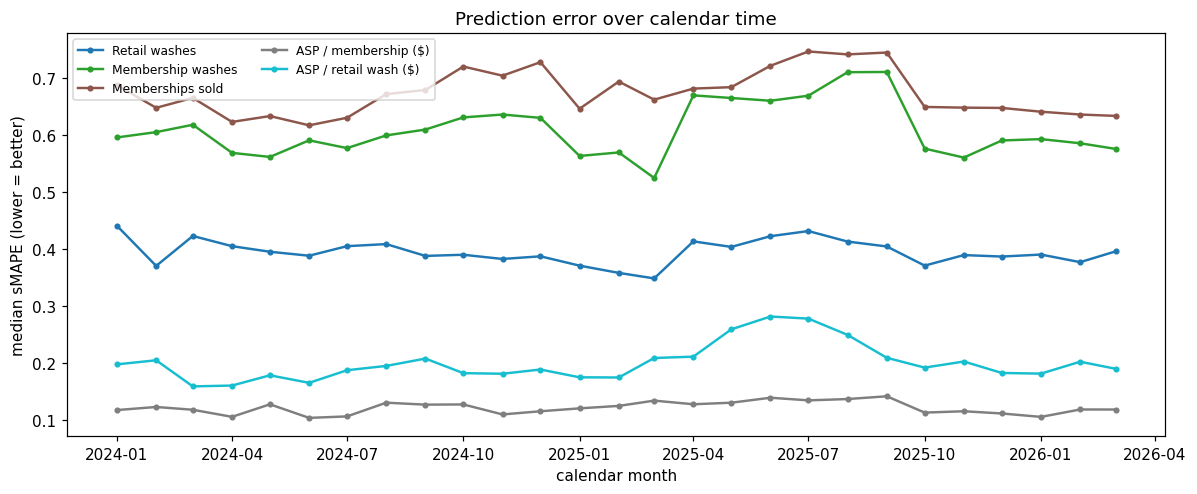

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.6))
colors = plt.cm.tab10(np.linspace(0, 1, len(order)))
for k, c in zip(order, colors):
    g = month_err[month_err.kpi == k].groupby("month")["smape"].median().sort_index()
    xs = [p.to_timestamp() for p in g.index]          # Period -> Timestamp for plotting
    ax.plot(xs, g.values, marker="o", ms=3, lw=1.6, color=c, label=LABELS[k])
ax.set_xlabel("calendar month")
ax.set_ylabel("median sMAPE (lower = better)")
ax.set_title("Prediction error over calendar time")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

## 8. Plot \u2014 example sites: predicted vs actual over calendar months
Four held-out sites with long histories. **Grey** = the cluster-mates the prediction is built
from, **red dashed** = LOSO prediction, **black** = the site's actual trajectory.

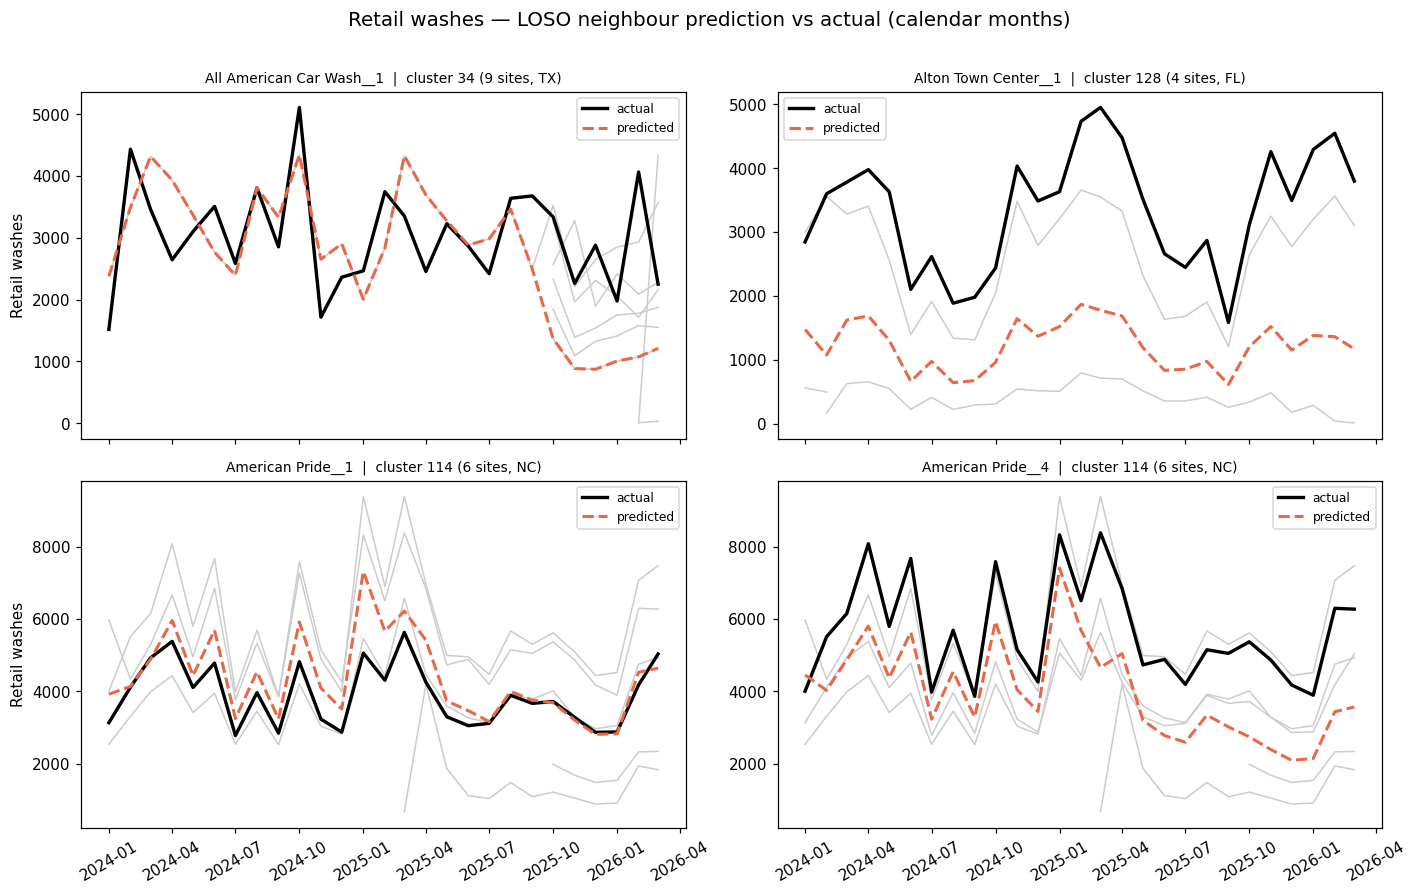

In [12]:
KPI_SHOW = "retail_wash_count"
mx = month_axis.to_timestamp()                        # PeriodIndex -> Timestamps for plotting
ncov = CAL[KPI_SHOW].notna().sum(axis=1)
cand = [u for u in si[si.cluster >= 0].index
        if ncov.get(u, 0) >= 18 and (si.cluster == si.loc[u, "cluster"]).sum() >= 4]
examples = cand[:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, uid in zip(axes.ravel(), examples):
    c = si.loc[uid, "cluster"]
    mates = si[(si.cluster == c) & (si.index != uid)].index
    for mid in mates:
        ax.plot(mx, CAL[KPI_SHOW].loc[mid].values, color="0.8", lw=1, zorder=1)
    pred = predict_holdout(uid, KPI_SHOW)
    ax.plot(mx, CAL[KPI_SHOW].loc[uid].values, color="black", lw=2.2,
            label="actual", zorder=3)
    ax.plot(mx, pred.values, color="#E8684A", lw=2.0, ls="--",
            label="predicted", zorder=3)
    ax.set_title(f"{uid}  |  cluster {int(c)} ({len(mates)+1} sites, {si.loc[uid,'state']})",
                 fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", labelrotation=30)
for ax in axes[:, 0]:
    ax.set_ylabel(LABELS[KPI_SHOW])
fig.suptitle(f"{LABELS[KPI_SHOW]} \u2014 LOSO neighbour prediction vs actual (calendar months)",
             y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Age axis removed.** Every comparison is on **real calendar months** \u2014 each site matched to its
  cluster-mates over the *same* period (no opening-date assumption; the panel is a fixed
  2024-01\u20262026-03 window, not per-site histories from opening).
- **Local geography adds real signal for membership / volume KPIs.** Overall (2024\u20132026) the 20 km
  cluster's IDW prediction beats the global "average site that month": **membership washes +15.5%**,
  **ASP/membership +7.3%**, **memberships sold +6.7%**, **retail washes +3.0%** uplift; trend-shape
  `sync_r` is high for wash counts (overall ~0.69\u20130.80).
- **Retail ASP is not geographic** \u2014 **\u221219.8% uplift overall** (the global average beats the local
  cluster); pricing is set per-operator, consistent with the clustering study.
- **2026 (Q1) kept and used smartly** \u2014 its 3 months feed the level metrics and overall `sync_r`;
  only its standalone per-year `sync_r` is suppressed (\u22656-month rule).
- **Raw min\u2013max containment is uninformative by construction (\u00a75b).** Leaving out a middle site is
  always inside, an extreme always outside \u2192 score = (n\u22122)/n = chance for *any* data, so it measures
  cluster size, not similarity (state lift \u2248 0 everywhere). Use the **uplift** (\u00a75) and a
  **calibrated** neighbour interval instead of the raw range.